In [31]:
import matplotlib.pyplot as plt 
from sklearn.datasets import make_blobs, make_moons, load_sample_image, load_digits
from sklearn.cluster import KMeans, DBSCAN
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture

print('Good imports!')

Good imports!


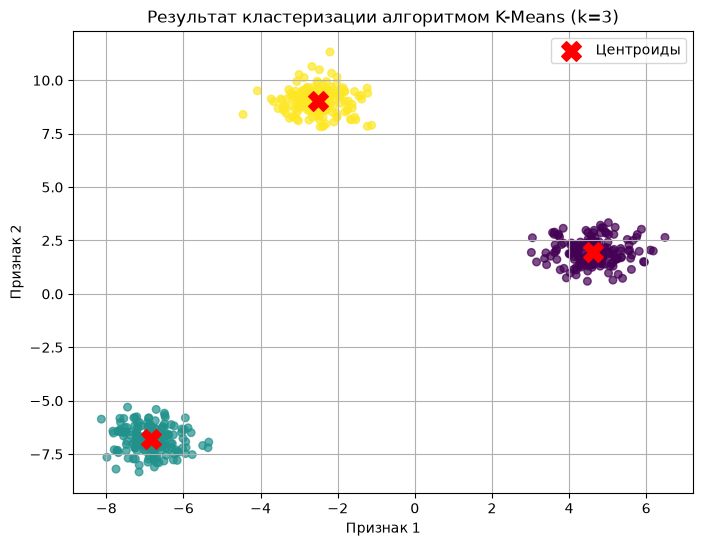

In [18]:
X, y_true = make_blobs(n_samples=500, centers=3, cluster_std=0.6, random_state=42)

kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
kmeans.fit(X)

y_kmeans = kmeans.predict(X)
centroids = kmeans.cluster_centers_

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=30, cmap='viridis', alpha=0.7)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Центроиды')

plt.title("Результат кластеризации алгоритмом K-Means (k=3)")
plt.xlabel("Признак 1")
plt.ylabel("Признак 2")
plt.legend()
plt.grid(True)
plt.show()

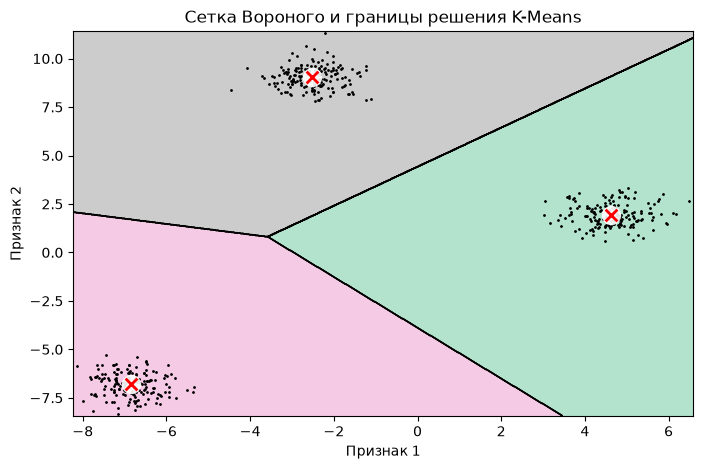

In [19]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='r'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=35, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=12,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]), cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]), colors='k', linewidths=1)
    plot_data(X)
    plot_centroids(clusterer.cluster_centers_)

plt.figure(figsize=(8, 5))
plot_decision_boundaries(kmeans, X)
plt.title("Сетка Вороного и границы решения K-Means")
plt.xlabel("Признак 1")
plt.ylabel("Признак 2")
plt.show()


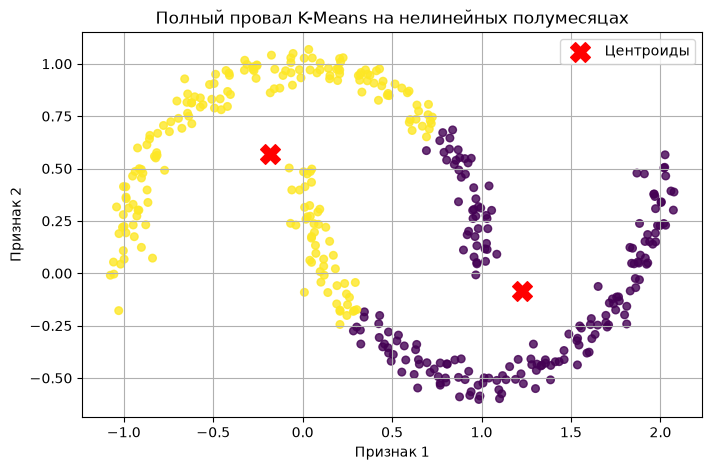

In [20]:
from sklearn.datasets import make_moons

X_moons, _ = make_moons(n_samples=400, noise=0.05, random_state=42)
kmeans_moons = KMeans(n_clusters=2, random_state=42, n_init='auto')
kmeans_moons.fit(X_moons)
y_pred_moons = kmeans_moons.predict(X_moons)

plt.figure(figsize=(8, 5))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_pred_moons, s=30, cmap='viridis', alpha=0.8)
plt.scatter(kmeans_moons.cluster_centers_[:, 0], kmeans_moons.cluster_centers_[:, 1], 
            c='red', s=200, marker='X', label='Центроиды')

plt.title("Полный провал K-Means на нелинейных полумесяцах")
plt.xlabel("Признак 1")
plt.ylabel("Признак 2")
plt.legend()
plt.grid(True)
plt.show()


Запуск сегментации картинки...


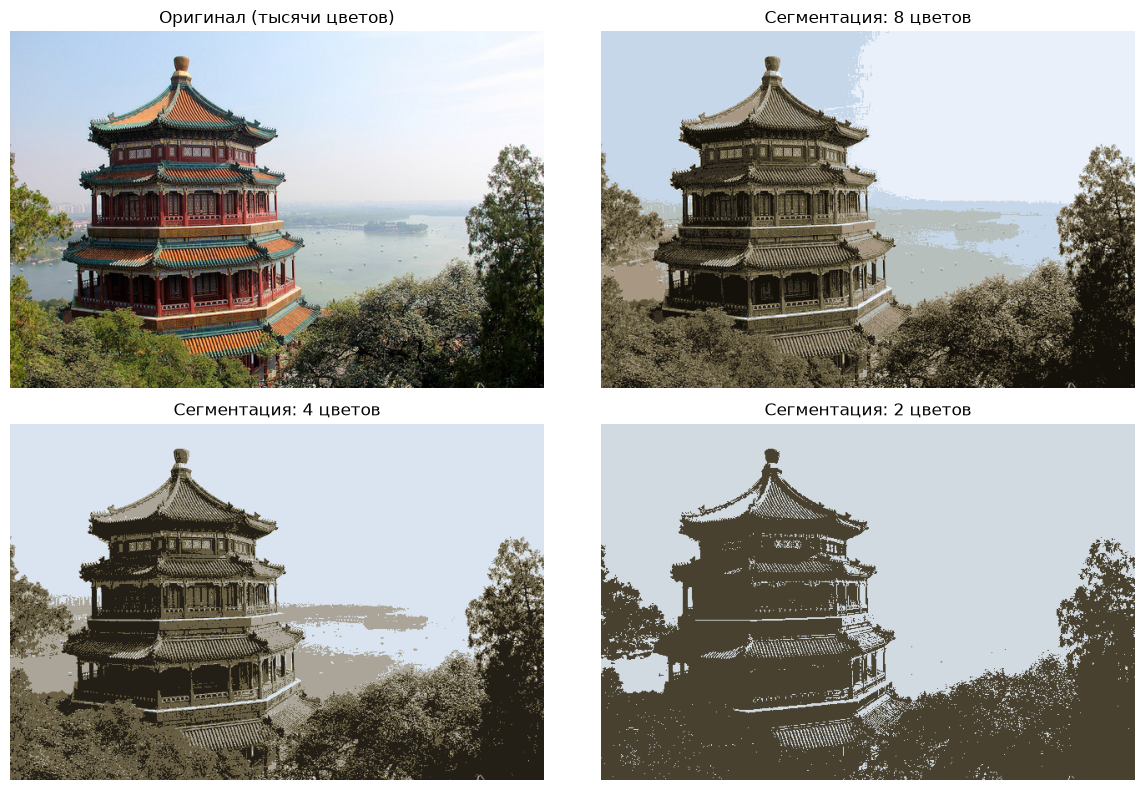

In [21]:
china_img = load_sample_image("china.jpg") 
image = china_img / 255.0
X_img = image.reshape(-1, 3) 

segmented_imgs = []
n_colors_list = [8, 4, 2]

print("Запуск сегментации картинки...")
for n_colors in n_colors_list:
    kmeans_img = KMeans(n_clusters=n_colors, random_state=42, n_init='auto')
    kmeans_img.fit(X_img)
    segmented_img = kmeans_img.cluster_centers_[kmeans_img.labels_]
    segmented_imgs.append(segmented_img.reshape(image.shape))

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(image)
plt.title("Оригинал (тысячи цветов)")
plt.axis("off")

for i, n_colors in enumerate(n_colors_list):
    plt.subplot(2, 2, i + 2)
    plt.imshow(segmented_imgs[i])
    plt.title(f"Сегментация: {n_colors} цветов")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [22]:
X_digits, y_digits = load_digits(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X_digits, y_digits, test_size=0.2, random_state=42)


log_reg = LogisticRegression(max_iter=10000, random_state=42)
log_reg.fit(X_train, y_train)
baseline_score = log_reg.score(X_test, y_test)
print(f"Точность базовой Логистической регрессии: {baseline_score:.2%}")


pipeline = Pipeline([
    ("kmeans", KMeans(n_clusters=50, random_state=42, n_init='auto')),
    ("log_reg", LogisticRegression(max_iter=10000, random_state=42))
])

pipeline.fit(X_train, y_train)
pipeline_score = pipeline.score(X_test, y_test)
print(f"Точность конвейера (K-Means + LogReg): {pipeline_score:.2%}")


Точность базовой Логистической регрессии: 97.50%
Точность конвейера (K-Means + LogReg): 97.22%


In [23]:
log_reg_v1 = LogisticRegression(max_iter=10000, random_state=42)
log_reg_v1.fit(X_train[:50], y_train[:50])
score_random = log_reg_v1.score(X_test, y_test)
print(f"Точность модели на 50 СЛУЧАЙНЫХ объектах: {score_random:.2%}")

k = 50
kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
X_digits_dist = kmeans.fit_transform(X_train)

representative_digit_indices = np.argmin(X_digits_dist, axis=0)
X_representative_digits = X_train[representative_digit_indices]
y_representative_digits = y_train[representative_digit_indices]

log_reg_v2 = LogisticRegression(max_iter=10000, random_state=42)
log_reg_v2.fit(X_representative_digits, y_representative_digits)
score_representative = log_reg_v2.score(X_test, y_test)
print(f"Точность модели на 50 ИЗБРАННЫХ объектах (K-Means): {score_representative:.2%}")


Точность модели на 50 СЛУЧАЙНЫХ объектах: 83.06%
Точность модели на 50 ИЗБРАННЫХ объектах (K-Means): 92.22%


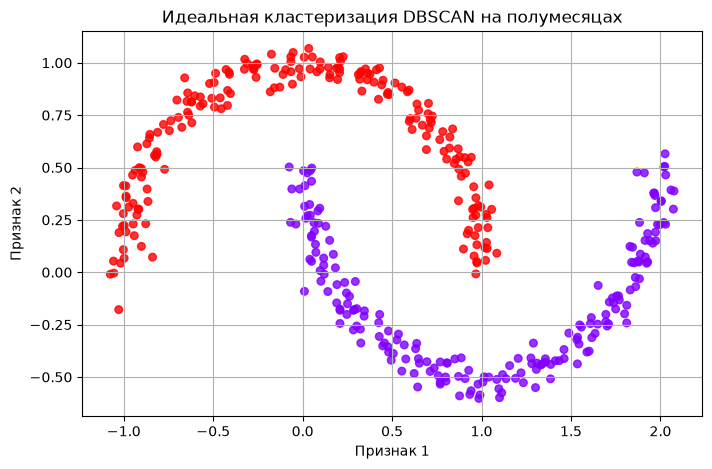

DBSCAN автоматически обнаружил кластеров: 2


In [24]:
dbscan = DBSCAN(eps=0.2, min_samples=5)
dbscan.fit(X_moons)

labels = dbscan.labels_

plt.figure(figsize=(8, 5))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=labels, cmap='rainbow', s=30, alpha=0.8)

noise_mask = (labels == -1)
if any(noise_mask):
    plt.scatter(X_moons[noise_mask, 0], X_moons[noise_mask, 1], 
                c='black', marker='x', s=50, label='Аномалии (Шум)')
    plt.legend()

plt.title("Идеальная кластеризация DBSCAN на полумесяцах")
plt.xlabel("Признак 1")
plt.ylabel("Признак 2")
plt.grid(True)
plt.show()

n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
print(f"DBSCAN автоматически обнаружил кластеров: {n_clusters_}")

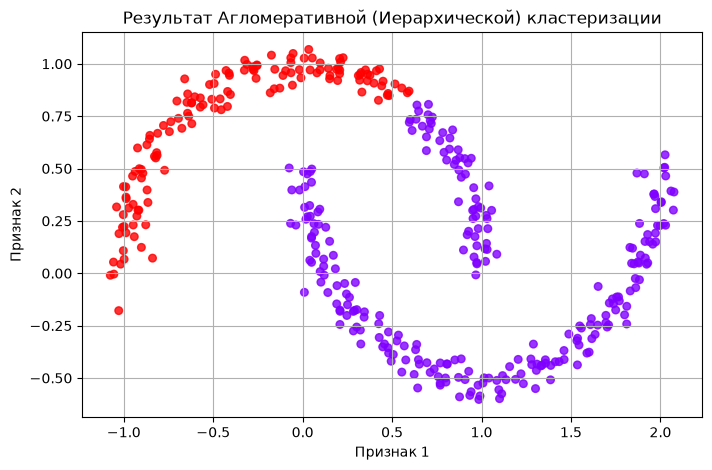

In [25]:
from sklearn.cluster import AgglomerativeClustering

agg_clf = AgglomerativeClustering(n_clusters=2)
y_pred_agg = agg_clf.fit_predict(X_moons)

plt.figure(figsize=(8, 5))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_pred_agg, cmap='rainbow', s=30, alpha=0.8)
plt.title("Результат Агломеративной (Иерархической) кластеризации")
plt.xlabel("Признак 1")
plt.ylabel("Признак 2")
plt.grid(True)
plt.show()


--- Вероятности принадлежности первых 3-х точек к кластерам ---
[[2.55449397e-096 1.00000000e+000 3.00695822e-191]
 [1.03128374e-255 1.04358048e-181 1.00000000e+000]
 [1.34227364e-097 1.00000000e+000 6.53229675e-239]]


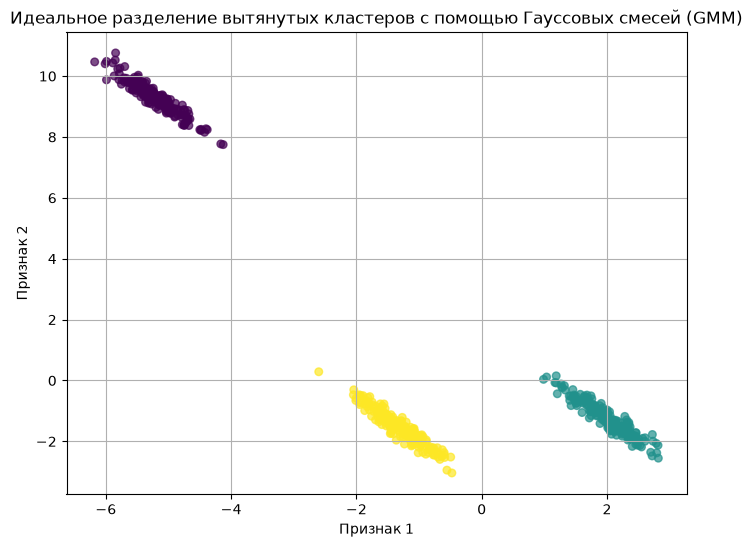

In [27]:
X_blobs, _ = make_blobs(n_samples=600, centers=3, cluster_std=0.5, random_state=42)
transformation = [[0.60834549, -0.63667341], [-0.40887718, 0.85253229]]
X_aniso = np.dot(X_blobs, transformation)

gm = GaussianMixture(n_components=3, n_init=10, random_state=42)
gm.fit(X_aniso)

y_pred_gm = gm.predict(X_aniso)

probabilities = gm.predict_proba(X_aniso)[:3]
print("--- Вероятности принадлежности первых 3-х точек к кластерам ---")
print(probabilities)

plt.figure(figsize=(8, 6))
plt.scatter(X_aniso[:, 0], X_aniso[:, 1], c=y_pred_gm, s=30, cmap='viridis', alpha=0.7)

plt.title("Идеальное разделение вытянутых кластеров с помощью Гауссовых смесей (GMM)")
plt.xlabel("Признак 1")
plt.ylabel("Признак 2")
plt.grid(True)
plt.show()

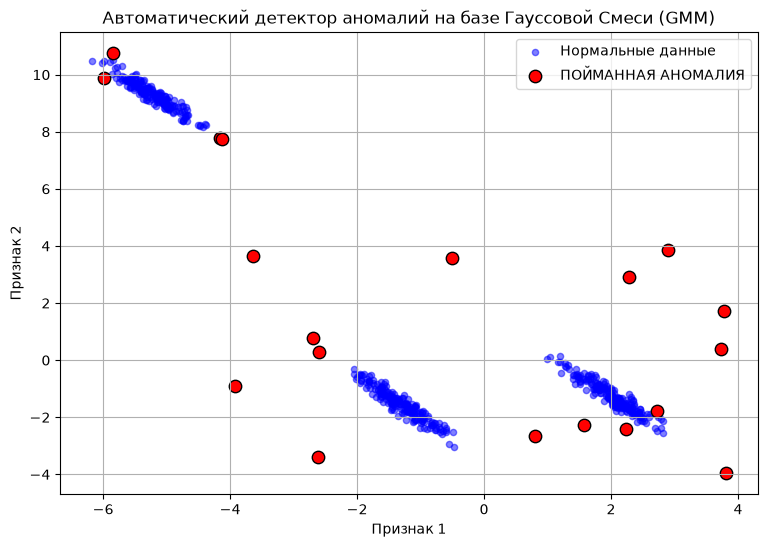

Порог плотности установлен на уровне: -4.5083
Всего модель задетектировала аномалий: 19 шт.


In [28]:
np.random.seed(4)
X_anomalies = np.random.uniform(low=-4, high=4, size=(15, 2))

X_mixed = np.vstack([X_aniso, X_anomalies])

densities = gm.score_samples(X_mixed)

percent_threshold = 3
density_threshold = np.percentile(densities, percent_threshold)

anomalies_mask = (densities < density_threshold)

plt.figure(figsize=(9, 6))
plt.scatter(X_mixed[~anomalies_mask, 0], X_mixed[~anomalies_mask, 1], c='blue', s=20, alpha=0.5, label="Нормальные данные")
plt.scatter(X_mixed[anomalies_mask, 0], X_mixed[anomalies_mask, 1], c='red', s=80, marker='o', edgecolors='black', label="ПОЙМАННАЯ АНОМАЛИЯ")

plt.title("Автоматический детектор аномалий на базе Гауссовой Смеси (GMM)")
plt.xlabel("Признак 1")
plt.ylabel("Признак 2")
plt.legend()
plt.grid(True)
plt.show()

print(f"Порог плотности установлен на уровне: {density_threshold:.4f}")
print(f"Всего модель задетектировала аномалий: {np.sum(anomalies_mask)} шт.")

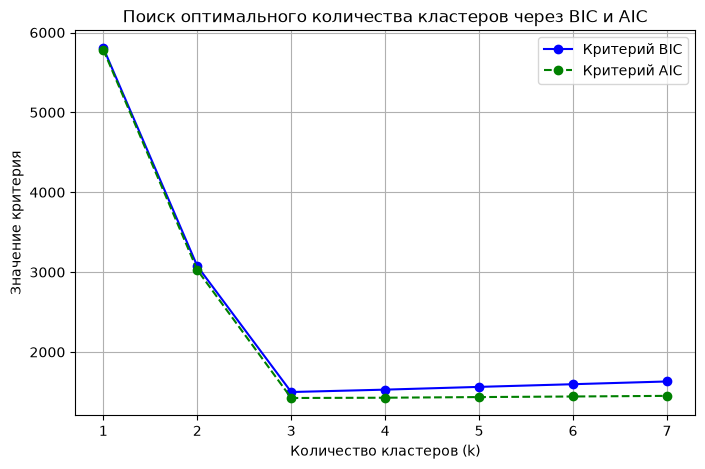

Математический оптимум по критерию BIC: k = 3


In [29]:
gms = [GaussianMixture(n_components=k, n_init=10, random_state=42).fit(X_aniso)
       for k in range(1, 8)]

bics = [model.bic(X_aniso) for model in gms]
aics = [model.aic(X_aniso) for model in gms]

plt.figure(figsize=(8, 5))
plt.plot(range(1, 8), bics, "bo-", label="Критерий BIC")
plt.plot(range(1, 8), aics, "go--", label="Критерий AIC")

plt.xlabel("Количество кластеров (k)")
plt.ylabel("Значение критерия")
plt.title("Поиск оптимального количества кластеров через BIC и AIC")
plt.legend()
plt.grid(True)
plt.show()

best_k = np.argmin(bics) + 1
print(f"Математический оптимум по критерию BIC: k = {best_k}")

In [32]:
bgm = BayesianGaussianMixture(n_components=10, n_init=10, random_state=42)
bgm.fit(X_aniso)

cluster_weights = np.round(bgm.weights_, 2)

print("--- Веса всех 10 кластеров в Байесовской модели ---")
for i, weight in enumerate(cluster_weights, 1):
    print(f"Кластер №{i}: вес = {weight}")

active_clusters = np.sum(cluster_weights > 0.01)
print(f"\nМодель самостоятельно оставила активными кластеров: {active_clusters}")

--- Веса всех 10 кластеров в Байесовской модели ---
Кластер №1: вес = 0.0
Кластер №2: вес = 0.33
Кластер №3: вес = 0.33
Кластер №4: вес = 0.33
Кластер №5: вес = 0.0
Кластер №6: вес = 0.0
Кластер №7: вес = 0.0
Кластер №8: вес = 0.0
Кластер №9: вес = 0.0
Кластер №10: вес = 0.0

Модель самостоятельно оставила активными кластеров: 3
